In [65]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [66]:
df_org=pd.read_csv('Telco_churn_dataset.csv')

In [67]:
df_org.sample(4)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
6118,9924-JPRMC,Male,0,No,No,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,118.20,8547.15,No
908,4694-PHWFW,Female,0,No,Yes,8,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.95,170.9,No
6346,9661-MHUMO,Male,1,Yes,Yes,1,Yes,No,DSL,No,...,No,Yes,No,No,Month-to-month,Yes,Credit card (automatic),49.25,49.25,Yes
5546,7880-XSOJX,Male,0,No,No,4,No,No phone service,DSL,Yes,...,No,Yes,No,No,Month-to-month,No,Mailed check,42.40,146.4,No


In [68]:
X = df_org.drop('Churn', axis=1)
Y = df_org['Churn']

In [69]:
Y = Y.map({
    'Yes':1,
    'No':0
})
Y = Y.astype(int)

In [70]:
Y.head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int32

In [71]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [72]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (FunctionTransformer)
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Evaluation Metrics
from sklearn.metrics import (

    accuracy_score,

    classification_report,

    confusion_matrix
)




num_columns = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

multi_columns = [
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod'
]

binary_columns = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling',
]


def basic_cleaning(df1):

    df1 = df1.copy()

    # Remove customerID
    df1 = df1.drop('customerID', axis=1)

    # Convert TotalCharges
    df1['TotalCharges'] = pd.to_numeric(df1['TotalCharges'],errors='coerce')

    # Fill missing values
    df1['TotalCharges'] = df1['TotalCharges'].fillna(df1['TotalCharges'].median())

    # Binary mapping
    binary_map = {
        'Yes':1,
        'No':0,
        'Female':0,
        'Male':1
    }

    for col in binary_columns:
        df1[col] = df1[col].map(binary_map)

    return df1

In [73]:
preprocessor = ColumnTransformer([('num', StandardScaler(), num_columns ),
                                  ('cat', OneHotEncoder(drop='first'),multi_columns)
                                  ],remainder='passthrough')

In [74]:
svm_base = Pipeline([
    ('cleaning',FunctionTransformer(basic_cleaning)),
    ('preprocessing',preprocessor),
    ('model', SVC(
    probability=True,

    random_state=42))])

# Train Model
svm_pipeline.fit(

    X_train,

    y_train
)

# Prediction
baseline_pred = svm_pipeline.predict(

    X_test
)

# Accuracy
baseline_acc = accuracy_score(

    y_test,

    baseline_pred
)

print(
    "Baseline Accuracy : ",

    baseline_acc
)

Baseline Accuracy :  0.8140525195173882


In [75]:
from sklearn.model_selection import GridSearchCV


# Create Pipeline
svm_pipeline = Pipeline([
    ('cleaning',FunctionTransformer(basic_cleaning)),
    ('preprocessing',preprocessor),
    ('model',SVC(probability=True))])

# Parameter Grid
param_grid = {

    'model__C': [

        0.1,

        1,

        10,

        100
    ],

    'model__kernel': [

        'linear',

        'rbf',

        'poly'
    ],

    'model__gamma': [

        'scale',

        'auto'
    ]
}

# GridSearchCV
grid_svm = GridSearchCV(

    estimator=svm_pipeline,

    param_grid=param_grid,

    cv=5,

    scoring='accuracy',

    verbose=1
)

# Train Model
grid_svm.fit(

    X_train,

    y_train
)
     

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,estimator,Pipeline(step...ility=True))])
,param_grid,"{'model__C': [0.1, 1, ...], 'model__gamma': ['scale', 'auto'], 'model__kernel': ['linear', 'rbf', ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,func,<function bas...0021D58AEAA20>


In [76]:

print("Best Parameters : ")

print(grid_svm.best_params_)

print("\nBest Accuracy : ")

print(grid_svm.best_score_)

Best Parameters : 
{'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'poly'}

Best Accuracy : 
0.799608984067795


In [77]:
svm_results = pd.DataFrame(

    grid_svm.cv_results_
)

svm_results[[

    'param_model__C',

    'param_model__kernel',

    'param_model__gamma',

    'mean_test_score'
]]

,param_model__C,param_model__kernel,param_model__gamma,mean_test_score
0,0.1,linear,scale,0.797125
1,0.1,rbf,scale,0.792333
2,0.1,poly,scale,0.791445
3,0.1,linear,auto,0.797125
4,0.1,rbf,auto,0.793575
5,0.1,poly,auto,0.734469
6,1.0,linear,scale,0.795883
7,1.0,rbf,scale,0.797302
8,1.0,poly,scale,0.799609
9,1.0,linear,auto,0.795883


In [78]:
best_svm_model = grid_svm.best_estimator_

best_pred = best_svm_model.predict(

    X_test
)

best_acc = accuracy_score(

    y_test,

    best_pred
)

print(
    "Tuned Model Accuracy : ",

    best_acc
)

Tuned Model Accuracy :  0.8097941802696949


In [79]:

comparison_df = pd.DataFrame({

    'Model': ['Baseline SVM','Tuned SVM'],

    'Accuracy': [baseline_acc,best_acc]
})

comparison_df
     

,Model,Accuracy
0,Baseline SVM,0.814053
1,Tuned SVM,0.809794


In [80]:
svm_base.fit(X_train, y_train)

,steps,"[('cleaning', ...), ('preprocessing', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,func,<function bas...0021D58AEAA20>
,inverse_func,None
,validate,False
,accept_sparse,False
,check_inverse,True
,feature_names_out,None
,kw_args,None


In [81]:
svm_pipeline.fit(X_train, y_train)

,steps,"[('cleaning', ...), ('preprocessing', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,func,<function bas...0021D58AEAA20>
,inverse_func,None
,validate,False
,accept_sparse,False
,check_inverse,True
,feature_names_out,None
,kw_args,None


In [82]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Baseline model predictions
baseline_pred = svm_base.predict(X_test)
baseline_prob = svm_base.predict_proba(X_test)[:,1]

# Tuned model predictions
tuned_pred =svm_pipeline.predict(X_test)
tuned_prob = svm_pipeline.predict_proba(X_test)[:,1]

# Comparison dataframe
comparison_df = pd.DataFrame({

    'Model': ['Baseline SVM', 'Tuned SVM'],

    'Accuracy': [
        accuracy_score(y_test, baseline_pred),
        accuracy_score(y_test, tuned_pred)
    ],

    'Precision': [
        precision_score(y_test, baseline_pred),
        precision_score(y_test, tuned_pred)
    ],

    'Recall': [
        recall_score(y_test, baseline_pred),
        recall_score(y_test, tuned_pred)
    ],

    'F1-Score': [
        f1_score(y_test, baseline_pred),
        f1_score(y_test, tuned_pred)
    ],

    'ROC-AUC': [
        roc_auc_score(y_test, baseline_prob),
        roc_auc_score(y_test, tuned_prob)
    ]
})

comparison_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Baseline SVM,0.814053,0.700361,0.520107,0.596923,0.808307
1,Tuned SVM,0.814053,0.700361,0.520107,0.596923,0.808316


          Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0  Baseline SVM  0.814053   0.700361  0.520107  0.596923  0.808307
1     Tuned SVM  0.814053   0.700361  0.520107  0.596923  0.808316


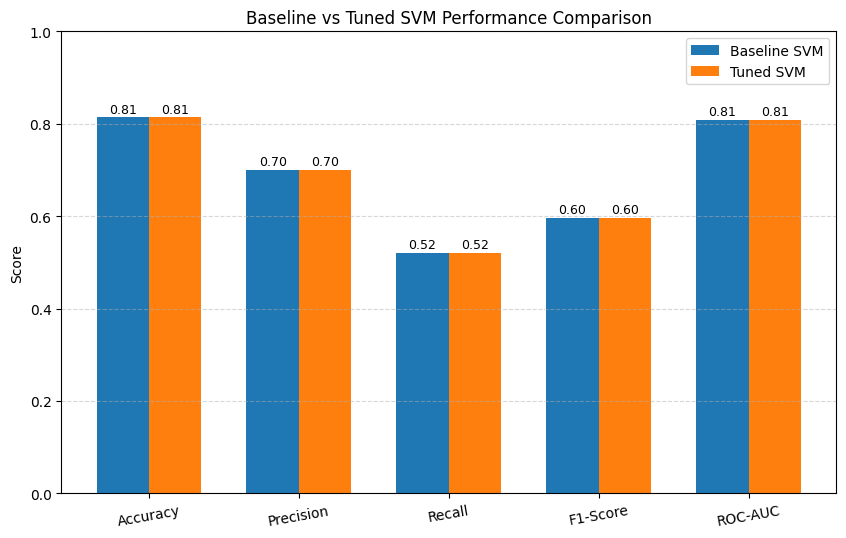

In [83]:
import matplotlib.pyplot as plt
import numpy as np

# Display dataframe
print(comparison_df)

# ─────────────────────────────
# GRAPH VISUALIZATION
# ─────────────────────────────

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

x = np.arange(len(metrics))
width = 0.35

baseline_values = comparison_df.iloc[0, 1:].values
tuned_values = comparison_df.iloc[1, 1:].values

plt.figure(figsize=(10,6))

bars1 = plt.bar(
    x - width/2,
    baseline_values,
    width,
    label='Baseline SVM'
)

bars2 = plt.bar(
    x + width/2,
    tuned_values,
    width,
    label='Tuned SVM'
)

# Labels
plt.xticks(x, metrics, rotation=10)
plt.ylabel("Score")
plt.title("Baseline vs Tuned SVM Performance Comparison")
plt.ylim(0,1)

# Value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.01,
            f'{height:.2f}',
            ha='center',
            fontsize=9
        )

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()


The comparative graph between Baseline SVM and Tuned SVM shows that both models achieved nearly identical performance across all evaluation metrics. Accuracy and ROC-AUC values were relatively high, indicating good classification capability. However, recall remained moderate, meaning some churn customers were still missed. Hyperparameter tuning did not produce significant improvement, suggesting that the baseline SVM model was already performing close to its optimal capability on the given dataset.